<a href="https://colab.research.google.com/github/greeshmakrishnan00/Machine-Learning/blob/main/Carprices__RegressionML_(Decision_Tree).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Decision Tree Algorithm - Regression**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Read

In [ ]:
df=pd.read_csv("/content/carprices (2).csv")
df

,Car Model,Mileage,Sell Price($),Age(yrs)
0,BMW X5,69000,18000,6
1,BMW X5,35000,34000,3
2,BMW X5,57000,26100,5
3,BMW X5,22500,40000,2
4,BMW X5,46000,31500,4
5,Audi A5,59000,29400,5
6,Audi A5,52000,32000,5
7,Audi A5,72000,19300,6
8,Audi A5,91000,12000,8
9,Mercedez Benz C class,67000,22000,6


# Data Cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Car Model      13 non-null     object
 1   Mileage        13 non-null     int64 
 2   Sell Price($)  13 non-null     int64 
 3   Age(yrs)       13 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 548.0+ bytes


In [ ]:
df.isnull().sum()

,0
Car Model,0
Mileage,0
Sell Price($),0
Age(yrs),0


In [ ]:
df.duplicated().sum()

np.int64(0)

# Visualization

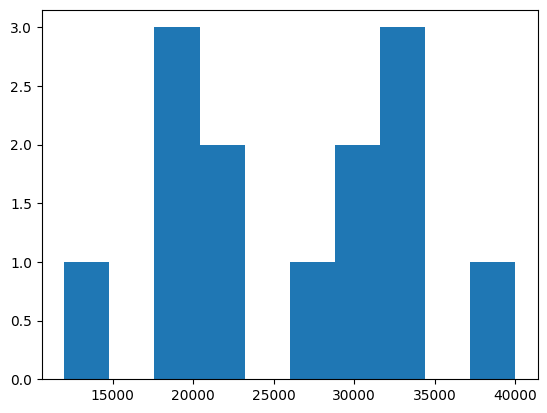

In [ ]:
plt.hist(df["Sell Price($)"])
plt.show()

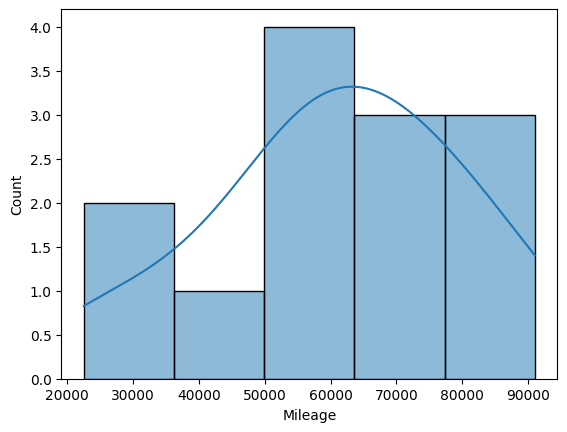

In [ ]:
sns.histplot(df["Mileage"],kde=True)
plt.show()

# Correlation analysis

In [ ]:
df

,Car Model,Mileage,Sell Price($),Age(yrs)
0,BMW X5,69000,18000,6
1,BMW X5,35000,34000,3
2,BMW X5,57000,26100,5
3,BMW X5,22500,40000,2
4,BMW X5,46000,31500,4
5,Audi A5,59000,29400,5
6,Audi A5,52000,32000,5
7,Audi A5,72000,19300,6
8,Audi A5,91000,12000,8
9,Mercedez Benz C class,67000,22000,6


In [ ]:
print(df["Car Model"].unique())

['BMW X5' 'Audi A5' 'Mercedez Benz C class']


In [ ]:
df["Car Model"].replace(['BMW X5','Audi A5','Mercedez Benz C class'],[0,1,2],inplace=True)

/tmp/ipykernel_2410/679516833.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Car Model"].replace(['BMW X5','Audi A5','Mercedez Benz C class'],[0,1,2],inplace=True)
/tmp/ipykernel_2410/679516833.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Car Model"].replace(['BMW X5','Audi A5','

# Corr_Matrix

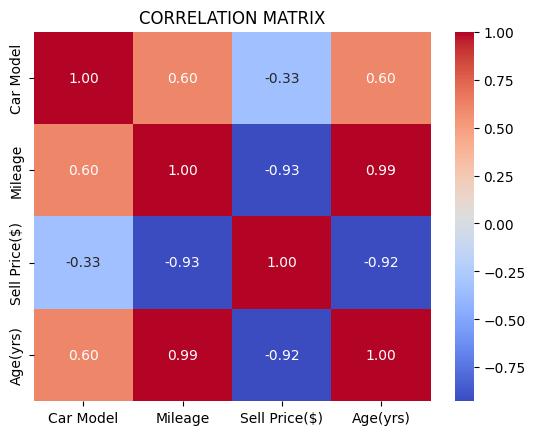

In [ ]:
corr_matrix=df.corr()
sns.heatmap(corr_matrix,annot=True,fmt="0.2f",cmap="coolwarm")
plt.title("CORRELATION MATRIX")
plt.show()

In [ ]:
df.drop(["Age(yrs)"],axis=1,inplace=True)

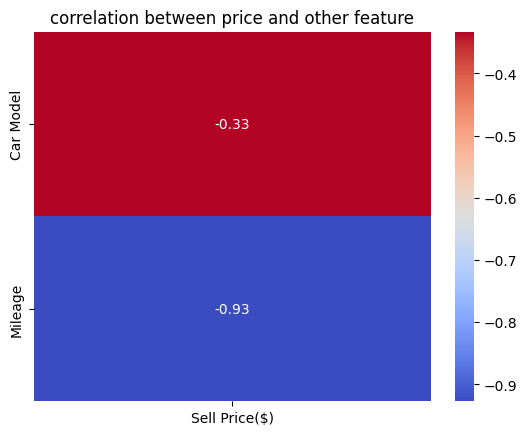

In [ ]:
from pickleshare import stat
status_corr=df.corr()["Sell Price($)"]
status_corr=status_corr.drop("Sell Price($)")
sns.heatmap(status_corr.to_frame(),annot=True,fmt=" .2f",cmap="coolwarm",cbar=True,annot_kws={'size':10})
plt.title("correlation between price and other feature")
plt.show()

# Outlier Checking and removing

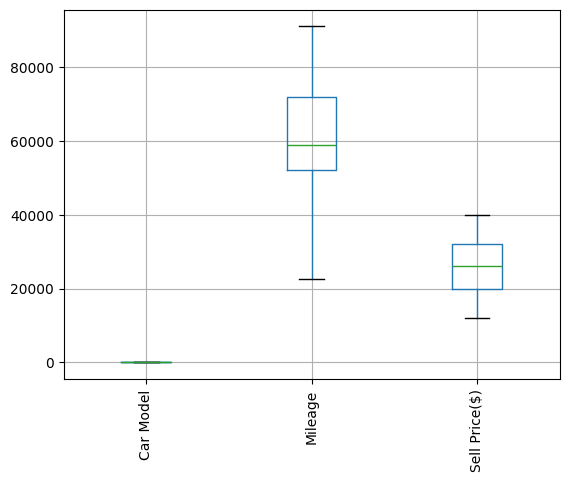

In [ ]:
df.boxplot()
plt.xticks(rotation=90)
plt.show()

In [ ]:
from numpy._core.defchararray import upper
def remove_outliers_iqr(df,exclude_column):
  for col in df.columns:
    if col==exclude_column:
        continue
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lowerbound=Q1-1.5*IQR
    upperbound=Q3+1.5*IQR
    df=df[(df[col]>=lowerbound)&(df[col]<=upperbound)]
  return df
df_cleaned=remove_outliers_iqr(df,exclude_column="Sell Price($)")
df=df_cleaned

# Data Scaling

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
features=["Car Model","Mileage"]
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[features])
scaled_df = pd.DataFrame(scaled_data, columns=features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score
import pandas as pd

x=df[["Car Model","Mileage"]]
y=df["Sell Price($)"]

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

model=DecisionTreeRegressor()
model.fit(x_train, y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")


Baseline model accuracy: 0.01
